   This is the shift-and-add multiplication algorithm -- it's essentially how
   you do long multiplication by hand in binary, but automated in hardware.
   

---
   ... 


MULTIPLY: shift and add
   Multiplication by conditional shift and add -- the same long multiplication
   you do by hand, but one bit at a time


THE ALGORITHM (repeat for each bit of `mp`)
   1. Test LSB of `mp`
      If LSB = 1 -> add `mc` to `pr` (product). If LSB = 0 -> do nothing.
   2. Shift `mc` left
      Doubles mc, aligning it with the next bit position.
   3. Shift `mp` right
      Drops the tested `LSB`, exposing the next bit.

---
      Multiplier (mp)   -- 4 bits, shift right -->
      Multiplicand (mc) -- 8 bits, shift left  <--
      Product (pr)      -- 8 bits, accumulates additions


BINARY LONG MULTIPLICATION (like decimal, but simpler!)
   For each bit of `mp` (from LSB to MSB): if the bit is 1, add a shifted copy 
   of `mc`. If 0, skip. This is exactly what the hardware does -- but one step
   at a time using shift registers.      



HARDWARE ARCHITECTURE (first version)
   Multiplicand (`mc`)
      `128-bit regiser`
      Starts in right half. Shifts LEFT each step, doubling its value to align
      with each bit position.
   Multiplier (`mp`)
      `64-bit register`
      Shifts RIGHT each step. The LSB is tested by the control unit to decide
      whether to add.
   Product (`pr`)
      `128-bit register`
      Accumulates partial products. When `mp`'s LSB = 1, the ALU adds `mc` to
      `pr`.
   Control 
      `Finite state machine`
      Tests LSB (`mp`), triggers conditional add, then signals both shifts. 
      Repeats 64 times for RISC-V.


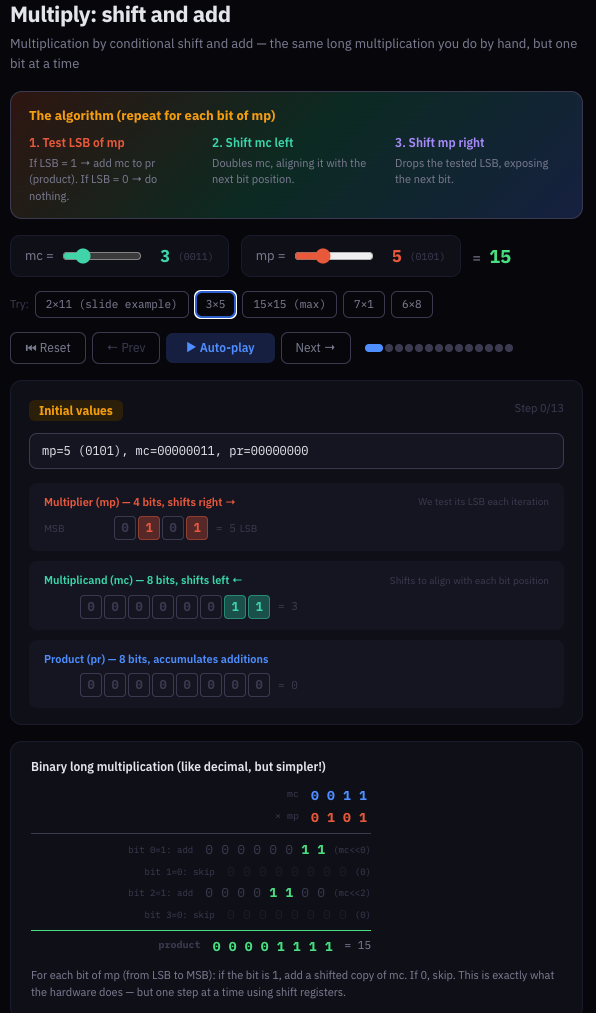

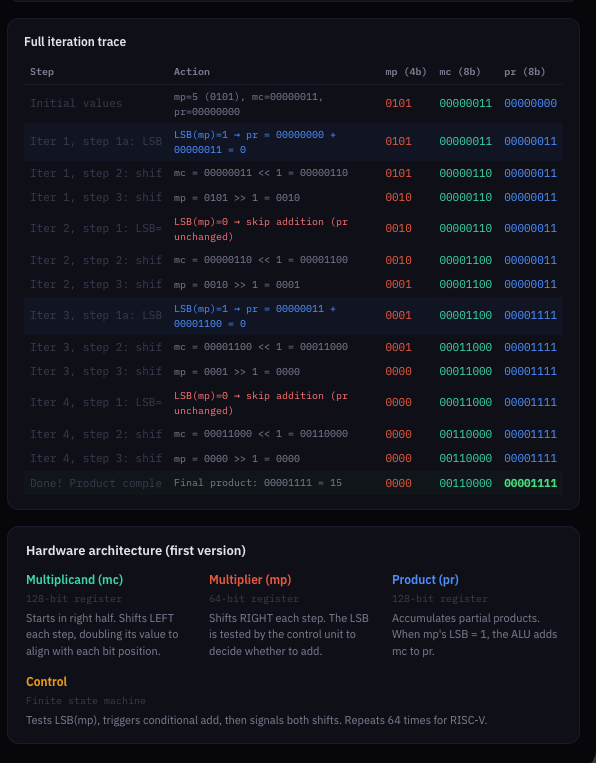

   these slides show a beautiful hardware optimisation journey -- three versions
   of the multiplier, each eliminating hardware by noticing redundancies. ...


---
   ...

   VERSION 1 -- The naive version you already know. `mc` is 8 bits wide and 
   shifts LEFT each iteration. The ALU needs to be 128 bits wide (wasteful!).
   Watch how `mc` grows: 0000 0010 --> 0000 0100 -> ... -> 0001 0000. Most of
   those bits are zeros -- wasted silicon.

   VERSION 2 -- The clever flip. `mc` stays fixed at 4 bits (0010). Instead of 
   `mc` moving let, `pr` SHIFTS RIGHT. The effect is identical: the relative
   position between `mc` and the product changes by one bit each step. But now
   the ALU only needs to add in the upper 4 bits of `pr`, so it shrinks to 64
   bits. Watch the `pr` register: after adding `mc` to the left half, the whole
   thing shifts right, and the product bits "fall into place" in the lower half.

   VERSION 3 -- The final trick. Notice how `pr` starts as `0000 0011` -- that's
   `mp` (0011) loaded directly into `pr`'s right half! There's no separate `mp`
   register at all. Each iteration, the LSB of `pr` is the multiplier bit being
   tested. After the shift right, that bit drops off and the next one appears.
   The `mp` bits naturally get confusmed as the product bits fill in from the 
   left. Watchh it closely: the right half starts as `0011` (mp=3), and by the
   end it's `0110` (product = 6).

   TRY 15x15 to see all three crucnhing through the maximum case -- every bit is
   1, so every iteration adds. The three arrive at the same answer (225) but V3
   does it with one fewer register.

   The comparison table at the bottom puts the savings in perspective: for a 
   64-bit RISC-V processor, V3 saves 192 bits of register storage compared to V1    
   -- that's 43% less hardware for the same computation. The green checkmark 
   ...



- 64-bit ALU
- 64-bit mc (fixed)
- No `mp` register!
- 128-bit `pr` (`mp` inside)


---
   

   V1 --> V2 INSIGHT: Shifting `mc` left by 1 each step is equivalent to 
   shifting `pr` rught by 1 -- either way, `mc`'s value aligns with a higher bit
   position relative to the accumulating product. But shifting `pr` instead 
   means `mc` never changes, so the ALU only needs to add in the upper half or
   `pr`. The `ALU` and `mc` register shrink from 128 bits to 64 bits!

   V2 --> V3 INSIGHT: In V2, both `mp` and `pr` shift right every iteration. The
   bits shifting out of mp's `LSB` are "used up" -- and the bits shifting into
   `pr`'s right half from the left are the new product bits. These two streams
   never collide! So put `mp` in `pr`'s right half at init. As `pr` shifts right
   , the `mp` bits naturally appear at the `LSB` position to be tested, then get
   pushed out as the product fills in from the left. One fewer register, zero
   wasted bits.

   ... the key insight is to REPLACE SUCCESSIVE ADDITIONS WHEN ENCOUNTERING A
   STRING OF ONES BY ONE ADDITION AND ONE SUBTRACTION. This insight is based on
   the property of a GEOMETRIC SERIES -- see next slide... 


   Booth's algorithm exploits the property of a geometric series, which enables
   replacing `k` additions by one subtraction and one addition. The proof is
   simple. There are, however, four cases that need to be considered in the 
   Booth's algorithm...


---
COMPARING THE THIRD ALGORITHM AND BOOTH'S ALGORITHM FOR POSITVE NUMBERS
   ... While the third multiplication algorithm considers only one bit at a time
   , the Booth algorithm considers two bits at a time. The two bits cover the
   four cases: 00, 01, 10, 11. For simple examples like this one, the Booth's
   algorithm does not show any benefit. 